In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
import os
import time
from rtm_pymmcore.data_structures import Channel, StimTreatment, SegmentationMethod
import rtm_pymmcore.utils as utils
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt
import gpax
import pandas as pd

In [7]:
from rtm_pymmcore.agents.bo_optimization_gpax import (
    BOptGPAX,
    BO_Parameter,
    BO_Objective,
    StandardScalerBounds,
    BO_Covariate,
    mock_df_results,
)

In [ ]:
# simulate an example run with two steerable parameters (x1, x2),
# one non-steerable covariate (cov1), and a single 1D objective (y).
bo_params = [
    BO_Parameter(name="x1", bounds=(0.0, 10.0), param_type="float", spacing=1.0),
    BO_Parameter(name="x2", bounds=(0.0, 6.0), param_type="float", spacing=1.0),
]
bo_covariates = [
    BO_Covariate(name="cov1"),
]
bo_objective = BO_Objective(name="y", goal="maximize")

# Noise knob for the mock measurements (0.0 -> deterministic)
MOCK_NOISE_SCALE = 1.0


class MockMicroscope:
    def run_experiment(self, df_acquire):
        return mock_df_results(
            df_acquire=df_acquire, n_samples=10, noise_scale=MOCK_NOISE_SCALE
        )


class DemoBOptGPAX(BOptGPAX):
    def _create_df_acquire_for_exp_cycle(self, parameters: dict) -> pd.DataFrame:
        # One acquisition point per cycle; microscope will return multiple samples.
        return pd.DataFrame([parameters])

    def _run_experiment_and_preprocess_results(
        self, df_acquire: pd.DataFrame
    ) -> pd.DataFrame:
        # needs to be implemented by user to run experiment based on df_acquire and preprocess results into df_results format
        # Implementation of running experiment and preprocessing results
        return self.microscope.run_experiment(df_acquire)


bo_agent = DemoBOptGPAX(
    microscope=MockMicroscope(),
    parameters_to_optimize=bo_params,
    objective_metric=bo_objective,
    bo_covariates=bo_covariates,
    n_iterations=12,
    acquisition_function="ei",  # try: "ei" or "ucb"
    ucb_beta=4.0,
    ei_xi=0.0,
)

bo_agent.run()

=== Initial sample 1/3: {'x1': np.float32(0.0), 'x2': np.float32(6.0)} ===
=== Initial sample 2/3: {'x1': np.float32(10.0), 'x2': np.float32(0.0)} ===
=== Initial sample 3/3: {'x1': np.float32(0.0), 'x2': np.float32(0.0)} ===

=== BO Iteration 1/12 ===


sample: 100%|██████████| 1200/1200 [00:00<00:00, 1272.68it/s, 7 steps of size 5.35e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.80      0.58      0.66      0.11      1.68    666.88      1.00
k_length[1]      1.63      1.40      1.30      0.05      3.44    816.59      1.00
k_length[2]      4.09      1.41      3.89      1.86      6.01    819.68      1.00
    k_scale      1.60      1.02      1.33      0.39      2.78    688.38      1.00
      noise      0.02      0.01      0.02      0.01      0.03    483.15      1.00

Computing robust acquisition over 1480 scenarios (74 grid points x 20 covariate samples)...
  best_f (scaled): 1.840921
  Acq values stats: min=0.000000, max=0.159198, mean=0.033070
  Robust acq stats: min=0.000017, max=0.093743
Selected parameters for next experiment: {'x1': np.float64(10.0), 'x2': np.float64(2.0)}

=== BO Iteration 2/12 ===


sample: 100%|██████████| 1200/1200 [00:02<00:00, 477.98it/s, 15 steps of size 3.73e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.78      0.57      0.63      0.11      1.58    704.88      1.00
k_length[1]      1.46      0.81      1.35      0.20      2.57    776.11      1.00
k_length[2]      5.44      1.60      5.17      2.89      7.79    547.28      1.00
    k_scale      1.55      0.92      1.32      0.38      2.74    502.14      1.00
      noise      0.01      0.00      0.01      0.01      0.01   1098.57      1.00

Computing robust acquisition over 1460 scenarios (73 grid points x 20 covariate samples)...
  best_f (scaled): 1.489406
  Acq values stats: min=0.000000, max=0.183103, mean=0.047444
  Robust acq stats: min=0.000002, max=0.165715
Selected parameters for next experiment: {'x1': np.float64(10.0), 'x2': np.float64(5.0)}

=== BO Iteration 3/12 ===


sample: 100%|██████████| 1200/1200 [00:02<00:00, 452.74it/s, 7 steps of size 5.08e-01. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.71      0.48      0.62      0.05      1.36    657.93      1.00
k_length[1]      1.44      0.57      1.42      0.53      2.36    452.91      1.00
k_length[2]      5.89      1.70      5.63      3.45      8.68    725.84      1.00
    k_scale      1.65      1.00      1.37      0.39      2.72    554.22      1.00
      noise      0.01      0.00      0.01      0.01      0.01    520.68      1.01

Computing robust acquisition over 1440 scenarios (72 grid points x 20 covariate samples)...
  best_f (scaled): 1.413416


KeyboardInterrupt: 

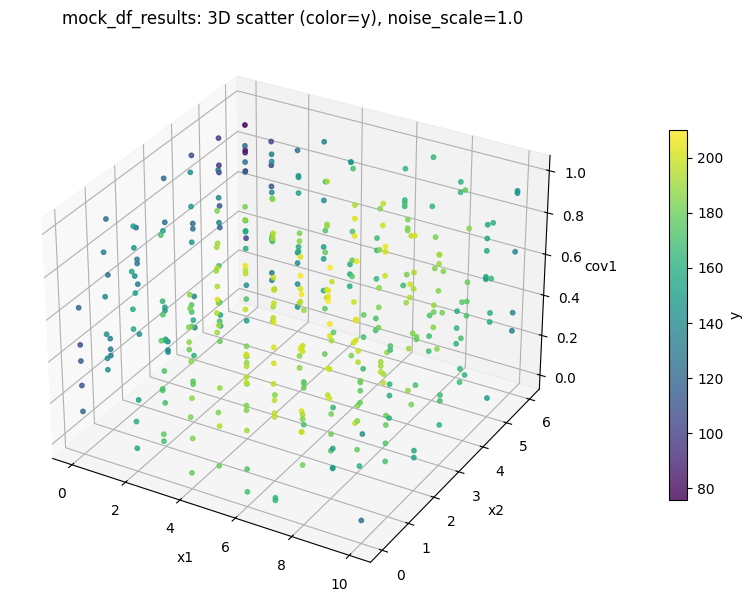

In [ ]:
# 3D visualization of the mock data distribution
from mpl_toolkits.mplot3d import Axes3D

# Build a full (x1,x2) grid and sample multiple cov1/y per point
x_total = bo_agent.x_total_linespace
df_acquire_grid = pd.DataFrame(x_total, columns=[p.name for p in bo_params])
df_mock = mock_df_results(
    df_acquire=df_acquire_grid, n_samples=5, noise_scale=MOCK_NOISE_SCALE
)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    df_mock["x1"].values,
    df_mock["x2"].values,
    df_mock["cov1"].values,
    c=df_mock["y"].values,
    cmap="viridis",
    s=10,
    alpha=0.8,
)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("cov1")
ax.set_title(f"mock_df_results: 3D scatter (color=y), noise_scale={MOCK_NOISE_SCALE}")
cbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.12)
cbar.set_label("y")
plt.show()